In [75]:
import numpy as np
import matplotlib.pyplot as plt

In [76]:
0.03927/2

0.019635

In [77]:
x0 = 0.25
y0 = 0
t_max = 6.2832
n_steps = 10
dt = []
h = []
t = []
x_a = []
y_a = []
x_n = []
y_n = []
for i in range(6):
    dt.append(t_max / n_steps)
    h.append(1/dt[i])
    t.append(np.linspace(0, t_max, n_steps+1))
    x_a.append(x0 * np.cos(t[i]) - y0 * np.sin(t[i]))
    y_a.append(x0 * np.sin(t[i]) + y0 * np.cos(t[i]))
    file_name = "../output_files/circ_" + str(dt[i]) + ".csv"
    csv_data = np.loadtxt(file_name, delimiter=',')
    x_n.append(csv_data[:,1])
    y_n.append(csv_data[:,2])
    n_steps *= 2
np.set_printoptions(precision=4)

In [80]:
RMSE = []
sum_e_2 = []
for i in range(6):
    N = t[i].shape[0]
    x_anal = x_a[i]
    x_num = x_n[i]
    y_anal = y_a[i]
    y_num = y_n[i]
    e = (x_anal - x_num)**2 + (y_anal - y_num)**2
    sum_e_2.append(np.sum(e))
    RMSE.append(np.sqrt(1/N * sum_e_2[i]))

print(RMSE)

[np.float64(0.537238781077962), np.float64(0.208241595045209), np.float64(0.08638880940701864), np.float64(0.03921604866751809), np.float64(0.018683246296753803), np.float64(0.009119476365447661)]


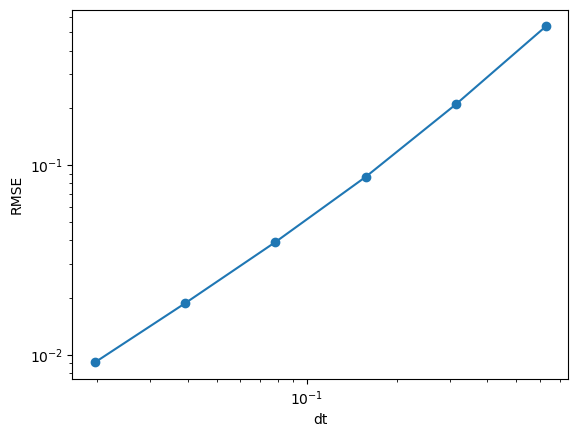

In [81]:
plt.plot(dt, RMSE, marker='o')
plt.xlabel("dt")
plt.ylabel("RMSE")
plt.yscale('log')
plt.xscale('log')

In [84]:
# Fit a linear polynomial (degree 1) to the data
slope, intercept = np.polyfit(dt, RMSE, 1)

# Print the slope
print(f'Slope: {slope}')

Slope: 0.8672591502145323


In [ ]:
# MSE = [0] * 5
# sum_e_2 = [0] * 5
# for i in range(1):
#     N = t[i].shape[0]
#     x_anal = x_a[i]
#     x_num = x_n[i]
#     y_anal = y_a[i]
#     y_num = y_n[i]
#     for j in range(N):
#         e = (x_anal[j] - x_num[j])**2 + (y_anal[j] - y_num[j])**2
#         sum_e_2[i] += e
#     MSE[i] = 1/N * sum_e_2[i]

# print(MSE)

[np.float64(0.2886255078941344), 0, 0, 0, 0]
